# **Day 16: Train/Test Split, Overfitting, Bias-Variance and Data Leakage**
*Module 3 - Data Preparation and Feature Engineering*

The single most important idea in ML: **a model must be judged on data it has never seen**. Today we see why, how models overfit, how the bias-variance trade-off explains it, and the many ways information can **leak** from the test set into training.

> A model must be tested on data it has never seen. Overfitting means memorising the training data instead of learning the general pattern. Data leakage means test information sneaks into training and makes the score look better than it is.
>
> *Example:* If we normalise all pixels using the mean of the whole image (including the test pixels) before splitting, the model has already "seen" the test set. That is leakage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(16)

## **1. Three Data Sets, Three Jobs**

| Set | Used for | Typical size |
|---|---|---|
| **Training** | Fitting model parameters | 60-80% |
| **Validation** (or CV on train) | Choosing models and hyperparameters | 10-20% |
| **Test** | One final, unbiased estimate | 10-20%, used **once** |

If we choose a model because it does well on the test set, the test set has become a validation set and its score is optimistic.

In [2]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=10, weights=[0.9], random_state=0)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=0)
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<5} n={len(yy):>4}  minority rate={yy.mean():.3f}")
# without stratify, small splits can have very different class rates
rates = [train_test_split(X, y, test_size=0.1, random_state=s)[3].mean() for s in range(200)]
print(f"Unstratified 10% test sets: minority rate ranges {min(rates):.3f} - {max(rates):.3f}")

train n= 600  minority rate=0.102
val   n= 200  minority rate=0.105
test  n= 200  minority rate=0.105
Unstratified 10% test sets: minority rate ranges 0.030 - 0.190


## **2. Underfitting and Overfitting**
We fit polynomials of increasing degree to noisy data from $y=\sin(2\pi x)$.

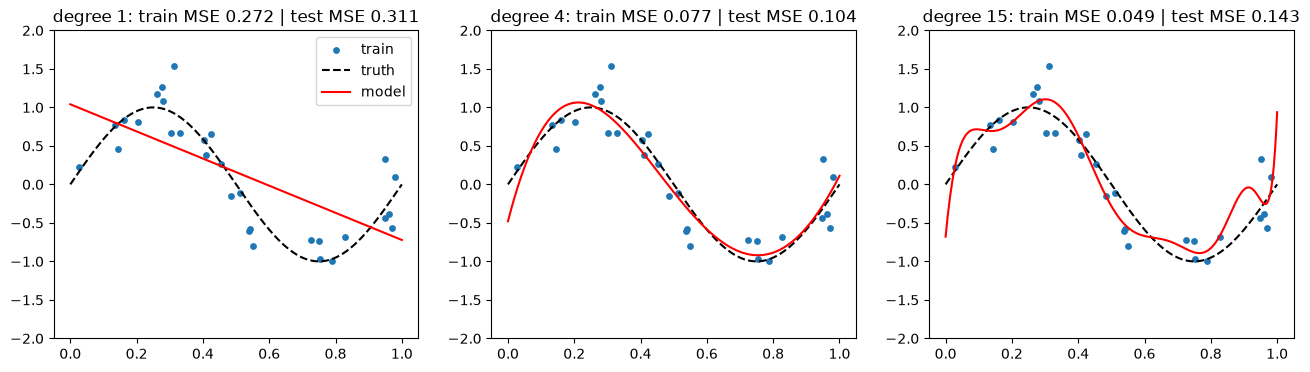

In [3]:
def make_data(n, seed):
    r = np.random.default_rng(seed)
    x = r.uniform(0, 1, n); return x, np.sin(2 * np.pi * x) + r.normal(0, 0.3, n)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

x_tr, y_tr = make_data(30, 1); x_te, y_te = make_data(500, 2)
xs = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, deg in zip(axes, [1, 4, 15]):
    m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(x_tr[:, None], y_tr)
    ax.scatter(x_tr, y_tr, s=15, label="train"); ax.plot(xs, np.sin(2 * np.pi * xs), "k--", label="truth")
    ax.plot(xs, m.predict(xs[:, None]), "r", label="model"); ax.set_ylim(-2, 2)
    tr_err = mean_squared_error(y_tr, m.predict(x_tr[:, None])); te_err = mean_squared_error(y_te, m.predict(x_te[:, None]))
    ax.set_title(f"degree {deg}: train MSE {tr_err:.3f} | test MSE {te_err:.3f}")
axes[0].legend(); plt.show()

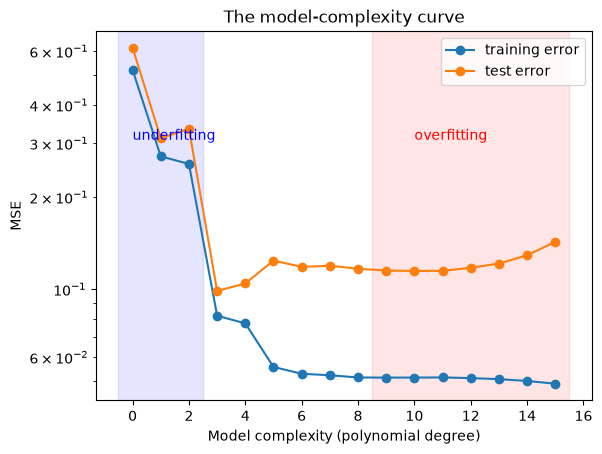

In [4]:
degrees = range(0, 16)
tr, te = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(x_tr[:, None], y_tr)
    tr.append(mean_squared_error(y_tr, m.predict(x_tr[:, None]))); te.append(mean_squared_error(y_te, m.predict(x_te[:, None])))
plt.semilogy(degrees, tr, "o-", label="training error"); plt.semilogy(degrees, te, "o-", label="test error")
plt.axvspan(-0.5, 2.5, alpha=0.1, color="b"); plt.axvspan(8.5, 15.5, alpha=0.1, color="r")
plt.text(0, max(te) / 2, "underfitting", color="b"); plt.text(10, max(te) / 2, "overfitting", color="r")
plt.xlabel("Model complexity (polynomial degree)"); plt.ylabel("MSE"); plt.legend(); plt.title("The model-complexity curve"); plt.show()

Training error always decreases with complexity. Test error is U-shaped. **Never select a model by training error.**

## **3. The Bias-Variance Decomposition**
For squared error, the expected test error at a point $x$ (averaged over random training sets) decomposes as:
$$\mathbb{E}\big[(y-\hat f(x))^2\big] = \underbrace{\big(\mathbb{E}\hat f(x) - f(x)\big)^2}_{\text{bias}^2} + \underbrace{\text{Var}\big(\hat f(x)\big)}_{\text{variance}} + \underbrace{\sigma^2}_{\text{noise}}$$
- **Bias**: error from wrong assumptions (too simple).
- **Variance**: sensitivity to the particular training sample (too flexible).
Let us measure both by training on 200 different training sets.

        bias^2  variance  bias^2+var+noise
degree                                    
1       0.1603    0.0227            0.2730
3       0.0033    0.0116            0.1048
5       0.0001    0.0218            0.1119
9       0.0004    0.0636            0.1540
12      0.0017    0.1873            0.2790


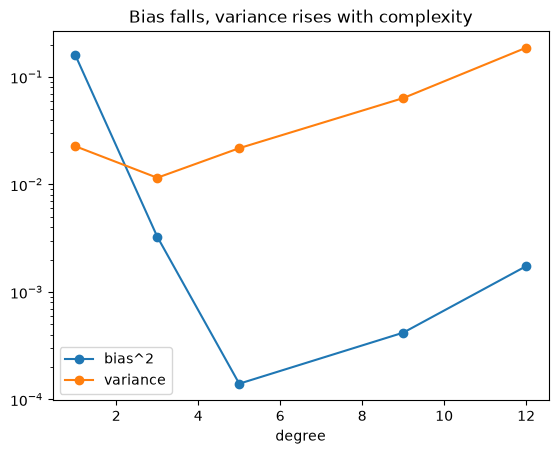

In [5]:
x_grid = np.linspace(0.05, 0.95, 50); f_true = np.sin(2 * np.pi * x_grid)
results = []
for d in [1, 3, 5, 9, 12]:
    preds = np.array([make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(xx[:, None], yy).predict(x_grid[:, None])
                      for xx, yy in (make_data(30, s) for s in range(200))])
    bias2 = np.mean((preds.mean(0) - f_true) ** 2); var = np.mean(preds.var(0))
    results.append({"degree": d, "bias^2": bias2, "variance": var, "bias^2+var+noise": bias2 + var + 0.09})
res = pd.DataFrame(results).set_index("degree")
print(res.round(4))
res[["bias^2", "variance"]].plot(marker="o", logy=True, title="Bias falls, variance rises with complexity"); plt.show()

## **4. More Data Reduces Variance**

In [6]:
for n in [15, 30, 100, 1000]:
    xx, yy = make_data(n, 5)
    m = make_pipeline(PolynomialFeatures(12), LinearRegression()).fit(xx[:, None], yy)
    print(f"degree 12 with n = {n:>4}: test MSE = {mean_squared_error(y_te, m.predict(x_te[:, None])):.3f}")

degree 12 with n =   15: test MSE = 0.233
degree 12 with n =   30: test MSE = 0.118
degree 12 with n =  100: test MSE = 0.104
degree 12 with n = 1000: test MSE = 0.093


## **5. Data Leakage: The Silent Killer**
Leakage = any information from the evaluation data (or from the future) that influences training. It produces excellent scores that **disappear in reality**.

| Leakage type | Example | Fix |
|---|---|---|
| Preprocessing leakage | Scaling / imputing / PCA fitted on all data before splitting | Fit inside a **Pipeline** |
| Feature-selection leakage | Selecting features using all labels, then CV | Selection inside the pipeline |
| Duplicate / near-duplicate leakage | Same patient, same field, augmented copies in train and test | **Group** splits |
| Temporal leakage | Training on the future to predict the past | **Time-based** splits |
| Target leakage | A feature computed from the target (Day 6) | Domain knowledge, audits |
| Spatial leakage | Neighbouring pixels in train and test | **Spatial** CV (Day 88) |

### Feature-selection leakage: perfect noise
Pure random features, random labels. Any honest method must score ~50%.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

Xn = rng.normal(size=(100, 5000)); yn = rng.integers(0, 2, 100)          # NO signal at all
X_sel = SelectKBest(f_classif, k=20).fit_transform(Xn, yn)                  # WRONG: uses all labels
wrong = cross_val_score(LogisticRegression(max_iter=1000), X_sel, yn, cv=5).mean()
right = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000)), Xn, yn, cv=5).mean()
print(f"Selection BEFORE CV (leaky): accuracy = {wrong:.2f}   <- looks like a discovery!")
print(f"Selection INSIDE CV (honest): accuracy = {right:.2f}")

Selection BEFORE CV (leaky): accuracy = 0.87   <- looks like a discovery!
Selection INSIDE CV (honest): accuracy = 0.45


This mistake has appeared in published genomics and remote sensing papers (Ambroise & McLachlan, 2002).

### Group leakage: repeated measurements

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, KFold
n_patients, per_patient = 60, 10
patient_effect = rng.normal(0, 1, (n_patients, 8))
Xg = np.repeat(patient_effect, per_patient, axis=0) + rng.normal(0, 0.3, (n_patients * per_patient, 8))
yg = np.repeat(rng.integers(0, 2, n_patients), per_patient)             # label is a property of the patient
groups = np.repeat(np.arange(n_patients), per_patient)
rf = RandomForestClassifier(n_estimators=200, random_state=0)
print("Random KFold (same patient in train and test):", cross_val_score(rf, Xg, yg, cv=KFold(5, shuffle=True, random_state=0)).mean().round(3))
print("GroupKFold  (patients kept separate)        :", cross_val_score(rf, Xg, yg, cv=GroupKFold(5), groups=groups).mean().round(3))

Random KFold (same patient in train and test): 0.952


GroupKFold  (patients kept separate)        : 0.468


The labels are random per patient, so the honest answer is ~50%. The random split "recognises" patients instead of learning anything general. Replace "patient" by "field", "image", "tree", "site", or "neighbouring pixels": the same trap.

# **Part 2: Going Deeper - Double Descent**

Classical theory says test error is U-shaped. Modern over-parameterised models (huge neural nets) show **double descent**: test error peaks when the number of parameters ~ number of samples (the *interpolation threshold*) and then **decreases again**. The minimum-norm solution chosen by `lstsq`/gradient descent acts as an implicit regulariser.

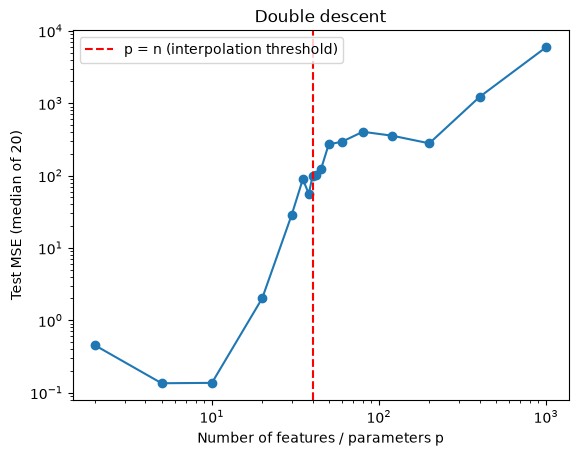

In [9]:
n_train = 40
xd, yd = make_data(n_train, 11); xdt, ydt = make_data(1000, 12)
centres = np.linspace(0, 1, 400)
def rff(x, p, seed=0):                                   # random Fourier-like features
    r = np.random.default_rng(seed); W = r.normal(0, 8, p); b = r.uniform(0, 2 * np.pi, p)
    return np.cos(np.outer(x, W) + b)
ps = [2, 5, 10, 20, 30, 35, 38, 40, 42, 45, 50, 60, 80, 120, 200, 400, 1000]
errs = []
for p in ps:
    e = []
    for s in range(20):
        w = np.linalg.lstsq(rff(xd, p, s), yd, rcond=None)[0]           # minimum-norm least squares
        e.append(mean_squared_error(ydt, rff(xdt, p, s) @ w))
    errs.append(np.median(e))
plt.semilogy(ps, errs, "o-"); plt.axvline(n_train, c="r", ls="--", label="p = n (interpolation threshold)")
plt.xscale("log"); plt.xlabel("Number of features / parameters p"); plt.ylabel("Test MSE (median of 20)")
plt.legend(); plt.title("Double descent"); plt.show()

## **Practice Problems**
1. Repeat the polynomial experiment with noise sd = 0.1 and 0.6. How does the best degree change?
2. Show preprocessing leakage: standardise `Xn` with mean/std computed on all data, then CV. Is the effect large here? Why is feature selection worse?
3. Simulate temporal leakage: create a trending time series, fit on a random split vs on the first 80% (predict the last 20%). Compare errors.

In [10]:
# Solution 1
for sd in [0.1, 0.6]:
    r = np.random.default_rng(1); xx = r.uniform(0, 1, 30); yy = np.sin(2 * np.pi * xx) + r.normal(0, sd, 30)
    errs_ = [mean_squared_error(np.sin(2 * np.pi * x_te), make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(xx[:, None], yy).predict(x_te[:, None])) for d in range(1, 13)]
    print(f"noise sd {sd}: best degree = {np.argmin(errs_) + 1}")
# Solution 2
Xs_all = (Xn - Xn.mean(0)) / Xn.std(0)
print("Scaling leakage on noise:", cross_val_score(LogisticRegression(max_iter=1000), Xs_all, yn, cv=5).mean().round(2),
      "-> small, because scaling does not use labels; selection does.")
# Solution 3
t = np.arange(300); series = 0.05 * t + np.sin(t / 5) + rng.normal(0, 0.3, 300)
lag = np.c_[series[:-1]]; target = series[1:]
from sklearn.ensemble import RandomForestRegressor
Xa, Xb, ya, yb = train_test_split(lag, target, test_size=0.2, random_state=0)
rand_err = mean_squared_error(yb, RandomForestRegressor(random_state=0).fit(Xa, ya).predict(Xb))
cut = int(0.8 * len(target))
time_err = mean_squared_error(target[cut:], RandomForestRegressor(random_state=0).fit(lag[:cut], target[:cut]).predict(lag[cut:]))
print(f"random split MSE {rand_err:.3f} vs time split MSE {time_err:.3f} (trees cannot extrapolate the trend)")

noise sd 0.1: best degree = 10
noise sd 0.6: best degree = 3
Scaling leakage on noise: 0.5 -> small, because scaling does not use labels; selection does.
random split MSE 0.307 vs time split MSE 2.955 (trees cannot extrapolate the trend)


## **Key References**
- Geman, S., Bienenstock, E., & Doursat, R. (1992). Neural networks and the bias/variance dilemma. *Neural Computation*, 4(1), 1-58.
- Ambroise, C., & McLachlan, G. J. (2002). Selection bias in gene extraction on the basis of microarray gene-expression data. *PNAS*, 99(10), 6562-6566.
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining. *ACM TKDD*, 6(4), 15.
- Belkin, M., Hsu, D., Ma, S., & Mandal, S. (2019). Reconciling modern machine-learning practice and the classical bias-variance trade-off. *PNAS*, 116(32), 15849-15854.
- Kapoor, S., & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. *Patterns*, 4(9), 100804.